In [1]:
import os

os.environ["CUDA_DEVICE_ORDER"]="PCI_BUS_ID"   
os.environ["CUDA_VISIBLE_DEVICES"]='0'

os.environ["HF_HOME"]="~/codes/.cache/huggingface"

In [2]:
import numpy as np

In [3]:
import matplotlib.pyplot as plt
def show_images(images, scores, test_artist, train_artists):
    n: int = len(images)
    f = plt.figure(figsize=(16, 2))
    for i in range(n):
        # Debug, plot figure
        ax = f.add_subplot(1, n, i + 1)
        if i==0:
            pass
            ax.title.set_text(test_artist)
        else:
            ax.title.set_text(str(np.round(scores[i-1], 4))+'\n'+train_artists[i-1])
            ax.axis('off')
        if images[i]==None:
            pass
        else:
            plt.imshow(images[i])

    plt.show(block=True)

In [4]:
from datasets import load_dataset

/home/yourname/.conda/envs/dtrak/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
import pickle

In [6]:
with open('../../data/indices/5000-0.5/idx-train.pkl', 'rb')  as handle:
    idx_train = pickle.load(handle)
len(idx_train)   

5000

In [7]:
with open('../../data/indices/5000-0.5/idx-val.pkl', 'rb')  as handle:
    idx_val = pickle.load(handle)
len(idx_val)

1000

In [8]:
import pandas as pd
df = pd.read_csv('/home/yourname/.cache/kagglehub/datasets/alexanderliao/artbench10/versions/2/ArtBench-10.csv')
#df = pd.read_csv('../../../../codes/artbench/ArtBench-10.csv')
df.head()

,name,artist,url,is_public_domain,length,width,label,split,cifar_index
0,frank-omeara_towards-night-and-winter.jpg,frank-omeara,https://uploads5.wikiart.org/00316/images/fran...,True,800,657,impressionism,train,43186
1,goldstein-grigoriy_morning.jpg,goldstein-grigoriy,https://uploads5.wikiart.org/images/grigoriy-g...,True,521,499,impressionism,train,41151
2,georges-lemmen_man-reading.jpg,georges-lemmen,https://uploads6.wikiart.org/images/georges-le...,True,800,612,impressionism,train,9754
3,theodor-aman_port-of-constantza-1882.jpg,theodor-aman,https://uploads6.wikiart.org/images/theodor-am...,True,560,336,impressionism,train,44244
4,niccolo-cannicci_il-passo-della-futa-1914.jpg,niccolo-cannicci,https://uploads3.wikiart.org/images/niccolo-ca...,True,2400,2322,impressionism,train,46885


In [9]:
df['path'] = df.apply(lambda x: "/home/yourname/neurips/artbench-merged/{}/{}".format(x['label'], x['name']), axis=1)
#df['path'] = df.apply(lambda x: "../../../../codes/artbench/data/artbench-10-imagefolder/{}/{}".format(x['label'], x['name']), axis=1)
df.head()

,name,artist,url,is_public_domain,length,width,label,split,cifar_index,path
0,frank-omeara_towards-night-and-winter.jpg,frank-omeara,https://uploads5.wikiart.org/00316/images/fran...,True,800,657,impressionism,train,43186,/home/yourname/neurips/artbench-merged/impre...
1,goldstein-grigoriy_morning.jpg,goldstein-grigoriy,https://uploads5.wikiart.org/images/grigoriy-g...,True,521,499,impressionism,train,41151,/home/yourname/neurips/artbench-merged/impre...
2,georges-lemmen_man-reading.jpg,georges-lemmen,https://uploads6.wikiart.org/images/georges-le...,True,800,612,impressionism,train,9754,/home/yourname/neurips/artbench-merged/impre...
3,theodor-aman_port-of-constantza-1882.jpg,theodor-aman,https://uploads6.wikiart.org/images/theodor-am...,True,560,336,impressionism,train,44244,/home/yourname/neurips/artbench-merged/impre...
4,niccolo-cannicci_il-passo-della-futa-1914.jpg,niccolo-cannicci,https://uploads3.wikiart.org/images/niccolo-ca...,True,2400,2322,impressionism,train,46885,/home/yourname/neurips/artbench-merged/impre...


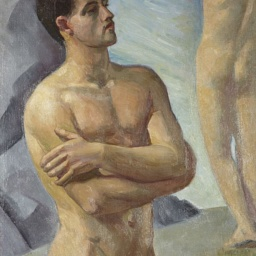

In [10]:
from datasets import Dataset, load_dataset, Image

train_dataset = Dataset.from_dict({"image": df.loc[idx_train]['path'].tolist(),
                                   "label": df.loc[idx_train]['label'].tolist(),
                                  }).cast_column("image", Image())
train_dataset[0]["image"]

In [11]:
#val_dataset =  dataset['test'].select(idx_val)
#val_dataset[0]["img"]

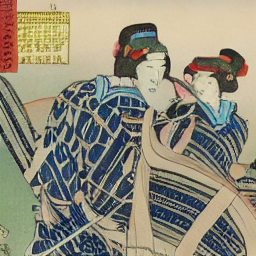

In [12]:
import pandas as pd
df = pd.DataFrame()
df['label'] = ['ukiyo_e']*500+['post_impressionism']*500
df['path'] = ['{}/{}.png'.format('../../saved/5000-0.5/gen', i) for i in range(1000)]

from datasets import DatasetDict, Dataset, load_dataset, Image
dataset = DatasetDict({
"train": Dataset.from_dict({
    "image": df['path'].tolist(),
    "label": df['label'].tolist(),
}).cast_column("image", Image()),})
gen_dataset = dataset["train"]
gen_dataset[0]["image"]

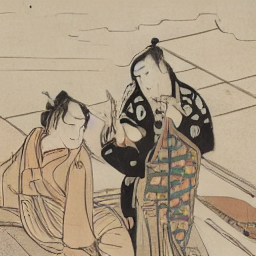

In [13]:
gen_dataset[2]["image"]

In [14]:
from sklearn.model_selection import train_test_split
_, test_index = train_test_split(range(1000), test_size=60, random_state=0)
test_index

[993,
 859,
 298,
 553,
 672,
 971,
 27,
 231,
 306,
 706,
 496,
 558,
 784,
 239,
 578,
 55,
 906,
 175,
 14,
 77,
 31,
 481,
 310,
 311,
 883,
 788,
 45,
 103,
 760,
 1,
 823,
 710,
 614,
 790,
 408,
 736,
 957,
 366,
 918,
 267,
 230,
 996,
 635,
 698,
 251,
 783,
 819,
 141,
 316,
 587,
 331,
 295,
 262,
 432,
 862,
 582,
 272,
 270,
 987,
 319]

In [15]:
with open("../../data/indices/5000-0.5/counter/idx-gen-sampled.pkl", 'wb') as handle:
    pickle.dump(test_index, handle)

In [16]:
test_index

[993,
 859,
 298,
 553,
 672,
 971,
 27,
 231,
 306,
 706,
 496,
 558,
 784,
 239,
 578,
 55,
 906,
 175,
 14,
 77,
 31,
 481,
 310,
 311,
 883,
 788,
 45,
 103,
 760,
 1,
 823,
 710,
 614,
 790,
 408,
 736,
 957,
 366,
 918,
 267,
 230,
 996,
 635,
 698,
 251,
 783,
 819,
 141,
 316,
 587,
 331,
 295,
 262,
 432,
 862,
 582,
 272,
 270,
 987,
 319]

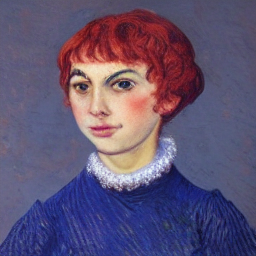

In [17]:
gen_dataset[test_index[0]]['image']

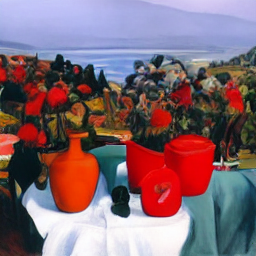

In [18]:
gen_dataset[test_index[1]]['image']

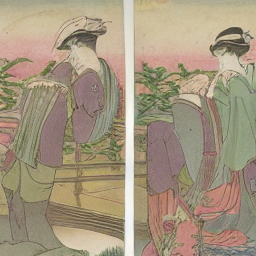

In [19]:
gen_dataset[test_index[2]]['image']

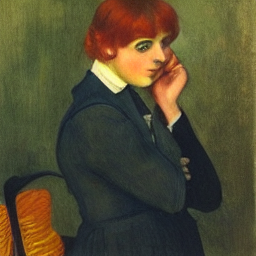

In [20]:
gen_dataset[test_index[3]]['image']

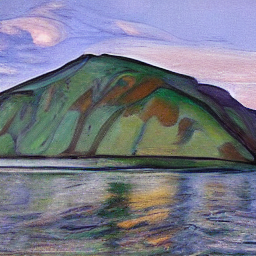

In [21]:
gen_dataset[test_index[4]]['image']

In [22]:
scores_list = []

In [23]:
with open("gen_5000_0.5_loss_100_5000000.0_0.2215678718104019.pkl", 'rb') as handle:
#with open("gen_5000_0.5_loss_100_5000000.0_0.20214663501351163.pkl", 'rb') as handle:
    scores = pickle.load(handle)
scores_list.append(scores)
scores.shape

(1000, 5000)

In [24]:
with open("gen_5000_0.5_mean-squared-l2-norm_100_5000000.0_0.2683277214572959.pkl", 'rb') as handle:
    scores = pickle.load(handle)
scores_list.append(scores)
scores.shape

FileNotFoundError: [Errno 2] No such file or directory: 'gen_5000_0.5_mean-squared-l2-norm_100_5000000.0_0.2683277214572959.pkl'

In [25]:
# load ground truth
my_list = [
    0,1,2,3,
    4,5,6,7,
    8,9,10,11,
    12,13,14,15,
    16,17,18,19,
    20,21,22,23,
    24,25,26,27,
    28,29,30,31,
    32,33,34,35,
    36,37,38,39,
    40,41,42,43,
    44,45,46,47,
    48,49,50,51,
    52,53,54,55,
    56,57,58,59,
    60,61,62,63,
          ]

In [26]:
loss_array_list = []

for i in my_list:
    for seed in [
        0,
                 1,
                 2,
                 # 3,
                 # 4,
                ]:
        for e_seed in [
            0, 
                       1, 
                       2
                      ]:
            with open('../../saved/5000-0.5/lds-val/sd-lora-sub-{}-{}/e-{}-gen.pkl'.format(i, seed, e_seed), 'rb')  as handle:
                loss_list = pickle.load(handle)
            margins = np.concatenate(loss_list, axis=-1) # -logp
            ####
            if (seed==0) and (e_seed)==0:
                loss_array = margins
            else:
                loss_array += margins
            
    loss_array = loss_array/(3*3)
    
    loss_array_list.append(loss_array)
lds_loss_array = np.stack(loss_array_list)
lds_loss_array.shape

(64, 1000, 1000)

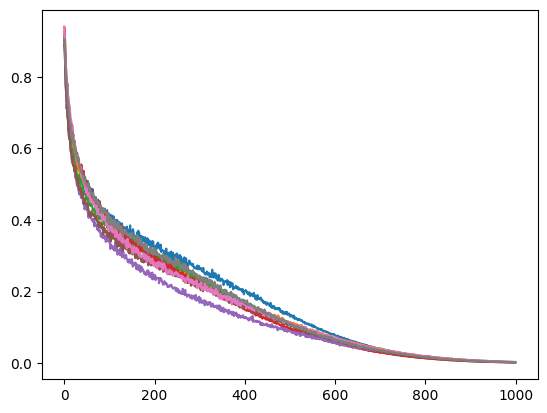

In [27]:
for i in range(1):
    for j in range(8):
        plt.plot(lds_loss_array[i, :, j], color="C{}".format(j))
    # break

In [28]:
mask_array_list = []

for i in my_list:
    # print(i)
    with open('../../data/indices/5000-0.5/lds-val/sub-idx-{}.pkl'.format(i), 'rb')  as handle:
        sub_idx_train = pickle.load(handle)
    # print(len(sub_idx_train))
    mask_array = np.in1d(idx_train, sub_idx_train)
        
    mask_array_list.append(mask_array)
    
lds_mask_array = np.stack(mask_array_list)
lds_mask_array.shape

(64, 5000)

In [29]:
lds_testset_correctness = lds_loss_array.mean(axis=1)
lds_testset_correctness.shape

(64, 1000)

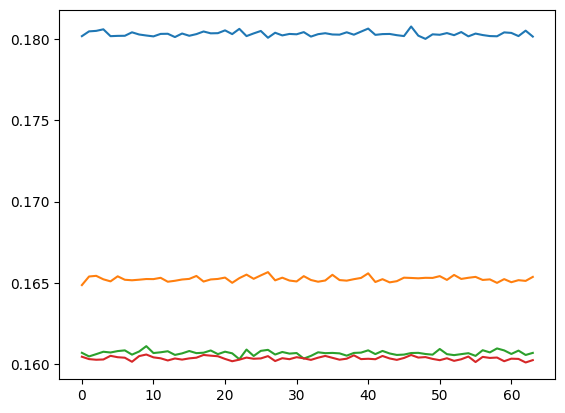

In [30]:
for j in range(4):
    plt.plot(lds_testset_correctness[:, j], color="C{}".format(j))
    # break
# plt.ylim(0.15, 0.2)

In [31]:
# compute lds
from scipy.stats import spearmanr, pearsonr
####
margins = lds_testset_correctness
infl_est_ = -scores_list[0]
# infl_est_ = -tmp
preds = lds_mask_array @ infl_est_.T
####
rs = []
ps = []

for ind in range(1000):
    r, p = spearmanr(preds[:, ind], margins[:, ind])
    # r, p = pearsonr(preds[:, ind], margins[:, ind])
    rs.append(r)
    ps.append(p)
    
rs, ps = np.array(rs), np.array(ps)
print(f'Correlation: {rs.mean():.3f} (avg p value {ps.mean():.6f})')

# tmp_1 = rs

Correlation: 0.222 (avg p value 0.203448)


In [32]:
# compute lds
from scipy.stats import spearmanr, pearsonr
####
margins = lds_testset_correctness
infl_est_ = -scores_list[0]
# infl_est_ = -tmp
preds = lds_mask_array @ infl_est_.T
####
rs = []
ps = []

for ind in test_index:
    r, p = spearmanr(preds[:, ind], margins[:, ind])
    # r, p = pearsonr(preds[:, ind], margins[:, ind])
    rs.append(r)
    ps.append(p)
    
rs, ps = np.array(rs), np.array(ps)
print(f'Correlation: {rs.mean():.3f} (avg p value {ps.mean():.6f})')

tmp_1 = rs

Correlation: 0.243 (avg p value 0.144822)


In [33]:
tmp_1

array([ 0.27147436,  0.25920626,  0.16932234,  0.28695055,  0.38479853,
        0.22081297,  0.24468864,  0.41826923,  0.11909341,  0.23122711,
        0.37257326,  0.32083333,  0.46419414,  0.10347985,  0.22344322,
        0.10572465,  0.21364469,  0.3382326 ,  0.34945055,  0.23049451,
        0.24922161,  0.24848901,  0.11336996,  0.30686813,  0.35082418,
        0.09748168,  0.07999084,  0.41868132,  0.30645604, -0.13809524,
        0.58855311,  0.21373626,  0.12174908,  0.22985348,  0.3456044 ,
        0.36982601,  0.19473443,  0.18873626,  0.04336081,  0.22152015,
        0.38356227,  0.19386447,  0.29569597,  0.27110806,  0.26657509,
        0.36098901, -0.03695055,  0.08649267,  0.22701465,  0.51863553,
        0.2231685 , -0.05251832,  0.36222527,  0.08163919,  0.12477249,
        0.15892857,  0.3268315 ,  0.3875    ,  0.22518315,  0.29459707])

In [34]:
# compute lds
from scipy.stats import spearmanr, pearsonr
####
margins = lds_testset_correctness
infl_est_ = -scores_list[1]
# infl_est_ = -tmp
preds = lds_mask_array @ infl_est_.T
####
rs = []
ps = []

for ind in range(1000):
    r, p = spearmanr(preds[:, ind], margins[:, ind])
    # r, p = pearsonr(preds[:, ind], margins[:, ind])
    rs.append(r)
    ps.append(p)
    
rs, ps = np.array(rs), np.array(ps)
print(f'Correlation: {rs.mean():.3f} (avg p value {ps.mean():.6f})')

# tmp_2 = rs

IndexError: list index out of range

In [35]:
# compute lds
from scipy.stats import spearmanr, pearsonr
####
margins = lds_testset_correctness
infl_est_ = -scores_list[1]
# infl_est_ = -tmp
preds = lds_mask_array @ infl_est_.T
####
rs = []
ps = []

for ind in test_index:
    r, p = spearmanr(preds[:, ind], margins[:, ind])
    # r, p = pearsonr(preds[:, ind], margins[:, ind])
    rs.append(r)
    ps.append(p)
    
rs, ps = np.array(rs), np.array(ps)
print(f'Correlation: {rs.mean():.3f} (avg p value {ps.mean():.6f})')

tmp_2 = rs

IndexError: list index out of range

In [36]:
tmp_2

NameError: name 'tmp_2' is not defined

In [37]:
scores_list[0][test_index].shape

(60, 5000)

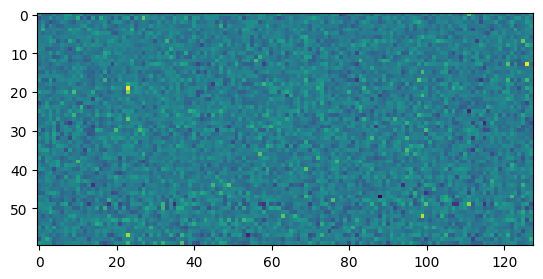

In [38]:
plt.imshow(scores_list[0][test_index][:, 0:128])

In [57]:
plt.imshow(scores_list[1][test_index][:, 0:128])

IndexError: list index out of range

In [58]:
np.random.seed(42)
scores_list.append(np.random.rand(1000, 5000))
len(scores_list)

2

In [59]:
for index, my_i in enumerate(test_index):
    print(index, my_i)
    for k in [
        # 250, 
        500, 1000, 2500, 
              # 5000
             ]:
        D_trak=-scores_list[0][my_i]
        topK_trak = np.arange(10000)[D_trak.argsort()[0:k]]

        D_ours=-scores_list[1][my_i]
        topK_ours = np.arange(10000)[D_ours.argsort()[0:k]]

        ####
        D_random=-scores_list[2][my_i]
        topK_random = np.arange(10000)[D_random.argsort()[0:k]]
        ####

        # print(len(np.intersect1d(topK_trak, topK_ours)))
        # print(len(np.union1d(topK_trak, topK_ours)))
        print(len(np.intersect1d(topK_trak, topK_ours))/len(np.union1d(topK_trak, topK_ours))) # Jaccard similarity

        ####
        new_idx_trak = np.delete(idx_train, topK_trak)
        # print(len(new_idx_trak))
        print(new_idx_trak[0:5])

        with open("../../data/indices/5000-0.5/counter/{}-{}-TRAK.pkl".format(index, k), 'wb') as handle:
            pickle.dump(new_idx_trak, handle)
        ####
        new_idx_ours = np.delete(idx_train, topK_ours)
        # print(len(new_idx_ours))
        print(new_idx_ours[0:5])

        with open("../../data/indices/5000-0.5/counter/{}-{}-Ours.pkl".format(index, k), 'wb') as handle:
            pickle.dump(new_idx_ours, handle)
        ####
        new_idx_random = np.delete(idx_train, topK_random)
        # print(len(new_idx_random))
        print(new_idx_random[0:5])

        with open("../../data/indices/5000-0.5/counter/{}-{}-Random.pkl".format(index, k), 'wb') as handle:
            pickle.dump(new_idx_random, handle)

0 993


IndexError: list index out of range